When the size of the studied system is below the exchange length, the magnetization of the system is uniform
and thus can be described using a single 3d vector. In this situation, the demagnetization field can be calculated
by simply multiplying the demagnetization tensor and the magnetization. Therefore, the demagnetization energy is
equivalent to an effective anisotropy.
Assuming that the external field $\vec{H}=(H, 0, 0)$, easy axis $\hat{u}=(\cos\theta, \sin\theta, 0)$ and unit
magnetization vector $\hat{m}= (\cos\phi, \sin\phi, 0)$, we have
$$
\begin{align}
E &= - K (\vec{m} \cdot \hat{u})^2 - \mu_0 M_s H \cos \phi \\
&= -\frac{K}{2}\left[ 1 + \cos (2(\theta-\phi))+ 4 h \cos\phi \right ]
\end{align}
$$
where $h=H/H_k$ and $H_k = 2K/(\mu_0 M_s)$. In the equilibrium state, the first derivative of the energy with respect to the
magnetization direction is zero, i.e.,
$$
\frac{\partial E}{\partial \phi} = K [-\sin (2(\theta-\phi)) + 2 h \sin \phi] = 0
$$
In principle, there will be a solution of $\phi$ for each given $h$ and $\theta$. The hysteresis loops can be constructed
by plotting $\cos\phi$ as a function of  $h$. The switching field can be obtained by extra setting the second derivative
of the energy with respect to the magnetization direction to zero, i.e.,
$$
\frac{\partial^2 E}{\partial \phi^2} = 2 K [\cos (2(\theta-\phi)) +  h \cos \phi] = 0
$$
The obtained switching field is
$$
h_s=\frac{\left(1-t^2+t^4\right)^{1 / 2}}{1+t^2}
$$
where $t=\tan ^{1 / 3} \theta$. Specifically, $h_s=1/2$ if $\theta=\pi/4$. In this example, we use JuMag to demostrate
this result.

We chose the system to be a cubic sample, so the demagnetization tensor is $N_x=N_y=N_z=1/3$.
That is, the demagnetization itself does not contribute to the effective anisotropy. So in this simulation,
we have ignored the demagnetization field. The JuMag script is shown below:

In [1]:
using JuMag

function relax_sw_loop()
    #We create a mesh for a cubic geometry 4nm x 4nm x 4nm
    mesh = FDMeshGPU(nx=4, ny=4, nz=4, dx=1e-9, dy=1e-9, dz=1e-9)

    #We create a simulation with the SD driver.
    sim = Sim(mesh, name="sw_cubic", driver="SD")

    #We set the saturation magnetization of the system.
    set_Ms(sim, 1.0e6)

    #Set the exchange constant
    add_exch(sim, 1.3e-11)

    #Set the initial state of the system.
    init_m0(sim, (-1, 1, 0))

    #Add the anisotropy
    add_anis(sim, 5e4, axis=(1,1,0))

    #Set the zeeman field.
    add_zeeman(sim,(0,0,0))

    #For each field, we relax the system to obtain its equilibrium state.
    for i=-100:5:100
        Hx = i*mT # A/m

        update_zeeman(sim, (Hx,0,0))

        #Relax the system with stopping_dmdt=0.05, the write_data function will be called if save_m_every is positive
        relax(sim, maxsteps=10000, stopping_dmdt=0.05, save_m_every=10000)

    end
end

relax_sw_loop (generic function with 1 method)

Run the function

In [2]:
relax_sw_loop()

[ Info: Running Driver : JuMag.EnergyMinimizationGPU{Float64}.
[ Info: step =    1  step_size=9.049774e-16    max_dmdt=3.562542e+02
[ Info: step =    2  step_size=3.882766e-10    max_dmdt=2.272724e+02
[ Info: step =    3  step_size=1.530684e-10    max_dmdt=4.205915e+02
[ Info: step =    4  step_size=9.193942e-11    max_dmdt=3.262495e+02
[ Info: step =    5  step_size=9.559083e-11    max_dmdt=5.200159e+01
[ Info: step =    6  step_size=7.177680e-11    max_dmdt=1.726828e+01
[ Info: step =    7  step_size=7.006919e-11    max_dmdt=4.189808e-01
[ Info: step =    8  step_size=7.056650e-11    max_dmdt=2.952732e-03
[ Info: max_dmdt is less than stopping_dmdt=0.05, Done!
[ Info: Running Driver : JuMag.EnergyMinimizationGPU{Float64}.
[ Info: step =    1  step_size=2.260505e-14    max_dmdt=9.220538e+00
[ Info: step =    2  step_size=7.265117e-11    max_dmdt=9.217512e+00
[ Info: step =    3  step_size=7.235173e-11    max_dmdt=3.783799e-02
[ Info: max_dmdt is less than stopping_dmdt=0.05, Done!
[ I

For the used anisotropy $K_u=5e4$ A/m$^3$, the expected switch field is $H_c = (1/2) H_K = 39788.7$ A/m.
We plot the hysteresis loops using the following function

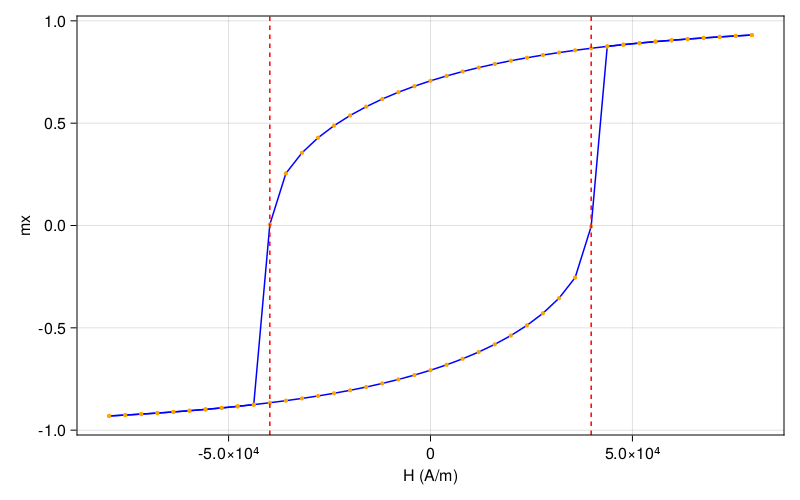

In [3]:
using DelimitedFiles
using CairoMakie

function plot_loop()
    folder = @__DIR__
    data = readdlm(folder*"/sw_cubic_sd.txt", skipstart=2)
    m, H = data[:, 3], data[:, 8]

    fig = Figure(resolution = (800, 500))
    ax = Axis(fig[1, 1],
        xlabel = "H (A/m)",
        ylabel = "mx"
    )

    scatterlines!(ax, H, m, markersize = 6, color = :blue, markercolor = :orange)
    scatterlines!(ax, -H, -m, markersize = 6, color = :blue, markercolor = :orange)

    expected = 39788.736 # A/m
    vlines!(ax, [expected, -expected], color = :red, linestyle = :dash)

    return fig

end

plot_loop()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*